# Real World Fine-tuning with APG

State alignment verification between MJX (differentiable) and native MuJoCo (non-differentiable, proxy for real world).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import functools

xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["MUJOCO_GL"] = "egl"
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ['JAX_LOG_COMPILES'] = '0'

# --- JAX Configuration ---
import jax
from jax import config

config.update("jax_enable_x64", True)
config.update("jax_default_matmul_precision", "high")
config.update("jax_debug_nans", False)

cache_path = "/data/jit_cache"
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
config.update("jax_compilation_cache_dir", cache_path)
config.update("jax_persistent_cache_min_entry_size_bytes", -1)
config.update("jax_persistent_cache_min_compile_time_secs", 1)

# Imports
import jax.numpy as jp
import matplotlib.pyplot as plt
import mediapy as media
import numpy as np
import pandas as pd

from mujoco_playground import locomotion
from mujoco_playground.config import locomotion_params
from mujoco_playground._src.locomotion.go2.Util import ValidationTools
from mujoco_playground._src.locomotion.go2.Util import render_utils
from mujoco_playground._src.locomotion.go2 import go2_constants as consts
from mujoco_playground._src.locomotion.go2 import managers as manager_lib
from mujoco_playground._src.locomotion.go2.managers import state_alignment_manager as state_alignment_lib

print("JAX configured. x64 enabled:", config.read("jax_enable_x64"))

Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Module` will soon be removed from the public API. Use `warp.Module` instead.
Warp DeprecationWarning: The symbol `warp.context.get_module` will soon be removed from the public API. Use `warp.get_module` instead.
Warp DeprecationWarning: The namespace `warp.math` will soon be removed from the public API. It can still be accessed from `warp._src.math` but might be changed or removed without notice.
JAX configured. x64 enabled: True


In [3]:
mjx_env_name = "Go2Joystick2"
mj_env_name = "Go2JoystickMujoco"
mjx_env_cfg = locomotion.get_default_config(mjx_env_name)
mj_env_cfg = locomotion.get_default_config(mj_env_name)
randomizer = locomotion.get_domain_randomizer(mjx_env_name)
apg_params = locomotion_params.brax_apg_config(mjx_env_name)

### Twin Model Template

`JoystickGo2Mujoco` exposes a `mujoco_model` config block for permanent twin-model overrides.

In [4]:
from mujoco_playground._src.locomotion.go2.JoystickGo2Mujoco import make_mujoco_model_template

mj_twin_template = make_mujoco_model_template()
mj_twin_template

body_inertia: {}
body_mass: {}
geom_friction: {}
geom_solimp: {}
geom_solref: {}
joint_armature: {}
joint_damping: {}
joint_frictionloss: {}
xml_path: /data/mujoco_playground/mujoco_playground/_src/locomotion/go2/xmls/scene.xml

## State Alignment Verification

Verifies State Alignment with a frozen residual policy from `go2_constants.RESIDUAL_PATH`. The aligned state uses the native MuJoCo transition for the forward value, while the gradient flows through the MJX transition and is scaled by `alpha`.

In [5]:
rollout_horizon = 8

EnvCls_mjx, EnvCls_mj, mjx_cfg_align, mj_cfg_align = ValidationTools.make_alignment_configs(use_mjx_xml_for_mujoco=True)

mjx_env_align = EnvCls_mjx(config=mjx_cfg_align)
mj_env_align = EnvCls_mj(config=mj_cfg_align)
state_alignment_manager = manager_lib.StateAlignmentManager(mjx_env_align, mj_env_align)

residual_policy = state_alignment_lib.load_residual_inference_fn(consts.RESIDUAL_PATH)

state_align_mjx = mjx_env_align.reset(jax.random.PRNGKey(0))
state_align_mj = mj_env_align.reset(jax.random.PRNGKey(0))

mjx_step, align_step = state_alignment_manager.make_step_fns(
    initial_mjx_state=state_align_mjx,
    initial_native_state=state_align_mj,
    policy_fn=residual_policy,
    horizon=rollout_horizon,
    loss_fn=ValidationTools.verification_loss_fn,
)

eta0 = jp.array(1.0, dtype=state_align_mjx.data.qpos.dtype)
alpha1 = jp.array(1.0, dtype=state_align_mjx.data.qpos.dtype)
alpha0 = jp.array(0.0, dtype=state_align_mjx.data.qpos.dtype)

metrics_mjx = mjx_step(eta0)
metrics_alpha1 = align_step(eta0, alpha1)
metrics_alpha0 = align_step(eta0, alpha0)

grad_mjx = jax.grad(lambda eta: mjx_step(eta)["loss"])(eta0)
grad_alpha1 = jax.grad(lambda eta: align_step(eta, alpha1)["loss"])(eta0)
grad_alpha0 = jax.grad(lambda eta: align_step(eta, alpha0)["loss"])(eta0)

verification_df = pd.DataFrame([
    {"case": "mjx_only", **{k: float(v) for k, v in metrics_mjx.items()}, "grad_dloss_deta": float(grad_mjx)},
    {"case": "align_alpha_1", **{k: float(v) for k, v in metrics_alpha1.items()}, "grad_dloss_deta": float(grad_alpha1)},
    {"case": "align_alpha_0", **{k: float(v) for k, v in metrics_alpha0.items()}, "grad_dloss_deta": float(grad_alpha0)},
])
verification_df["grad_abs_diff_vs_mjx"] = np.abs(verification_df["grad_dloss_deta"] - float(grad_mjx))

print("Residual policy path:", consts.RESIDUAL_PATH)
print("Rollout horizon:", rollout_horizon)
verification_df

Residual policy path: /data/mujoco_playground/mujoco_playground/experimental/learning/checkpoints/Go2Joystick2-20260403-070849-apg/params.pkl
Rollout horizon: 8


,case,final_done,loss,mean_ctrl_norm,mean_qpos_gap,mean_qvel_gap,reward_sum,valid_steps,grad_dloss_deta,grad_abs_diff_vs_mjx
0,mjx_only,0.0,2.159995,4.177964,0.111677,4.129170,0.213020,8.0,0.077597,0.000000
1,align_alpha_1,0.0,2.134077,4.172679,0.030848,2.140594,0.093232,8.0,0.120807,0.043209
2,align_alpha_0,0.0,2.134077,4.172679,0.030848,2.140594,0.093232,8.0,0.000000,0.077597


## Gradient Comparison

Cosine similarity and norm differences between MJX-only and aligned rollout gradients.

In [6]:
grad_df = ValidationTools.gradient_comparison_metrics(
    grad_mjx, grad_alpha1, grad_alpha0,
    loss_mjx=float(metrics_mjx["loss"]),
    loss_alpha1=float(metrics_alpha1["loss"]),
    loss_alpha0=float(metrics_alpha0["loss"]),
)
grad_df

,case,cosine_vs_mjx,norm,norm_mjx,norm_diff,loss,loss_mjx
0,alpha_1,1.0,0.120807,0.077597,0.043209,2.134077,2.159995
1,alpha_0,0.0,0.000000,0.077597,-0.077597,2.134077,2.159995


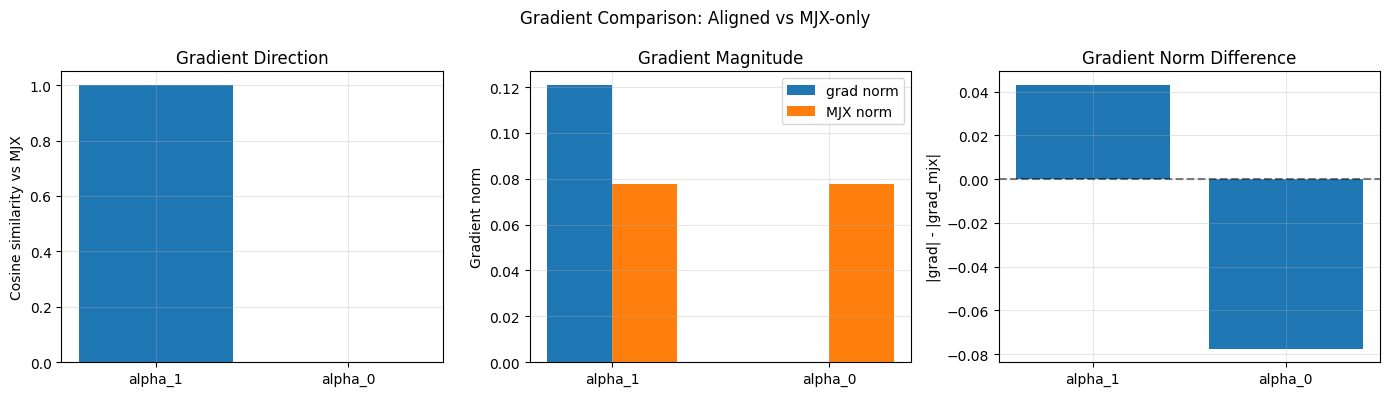

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cases = grad_df["case"].tolist()
axes[0].bar(cases, grad_df["cosine_vs_mjx"].to_numpy())
axes[0].set_ylabel("Cosine similarity vs MJX")
axes[0].set_title("Gradient Direction")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)

x = np.arange(len(cases))
w = 0.3
axes[1].bar(x - w/2, grad_df["norm"].to_numpy(), w, label="grad norm")
axes[1].bar(x + w/2, grad_df["norm_mjx"].to_numpy(), w, label="MJX norm")
axes[1].set_ylabel("Gradient norm")
axes[1].set_title("Gradient Magnitude")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cases)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].bar(cases, grad_df["norm_diff"].to_numpy())
axes[2].set_ylabel("|grad| - |grad_mjx|")
axes[2].set_title("Gradient Norm Difference")
axes[2].axhline(y=0, color="black", linestyle="--", alpha=0.5)
axes[2].grid(alpha=0.3)

fig.suptitle("Gradient Comparison: Aligned vs MJX-only")
fig.tight_layout()
plt.show()

## Policy Rollout Visualization

In [8]:
policy_command = jp.array([0.4, 0.0, 0.0], dtype=state_align_mjx.data.qpos.dtype)
viz_horizon = 240
render_every = 2
render_height = 480
render_width = 640
freeze_command_steps = 1_000_000
align_rollout_alpha = alpha1


def reset_with_command(env, command, seed=0):
    state = env.reset(jax.random.PRNGKey(seed))
    info = dict(state.info)
    info["command"] = jp.asarray(command, dtype=info["command"].dtype)
    info["steps_until_next_cmd"] = jp.array(freeze_command_steps, dtype=jp.int32)
    return state.replace(info=info)


def unstack_states(stacked_states):
    return [
        jax.tree_util.tree_map(lambda x, i=i: x[i], stacked_states)
        for i in range(stacked_states.reward.shape[0])
    ]


def rollout_cases(command, horizon=viz_horizon, alpha=align_rollout_alpha):
    initial_mjx_state = reset_with_command(mjx_env_align, command)
    initial_native_state = reset_with_command(mj_env_align, command)
    mjx_rollout_fn, align_rollout_fn = state_alignment_manager.make_rollout_fns(
        initial_mjx_state=initial_mjx_state,
        initial_native_state=initial_native_state,
        policy_fn=residual_policy,
        horizon=horizon,
    )
    mjx_rollout = mjx_rollout_fn(eta0)
    align_rollout = align_rollout_fn(eta0, alpha)
    return {
        "mjx_only": [initial_mjx_state, *unstack_states(mjx_rollout["mjx_state"])],
        "alignment": [initial_mjx_state, *unstack_states(align_rollout["mjx_state"])],
        "native": [initial_native_state, *unstack_states(align_rollout["native_state"])],
    }


rollouts = rollout_cases(policy_command)
traj_mjx = ValidationTools.build_trajectory_dataframe(rollouts["mjx_only"], mjx_env_align)
traj_align = ValidationTools.build_trajectory_dataframe(rollouts["alignment"], mjx_env_align)
traj_native = ValidationTools.build_trajectory_dataframe(rollouts["native"], mj_env_align)
gaps = ValidationTools.build_state_gap_dataframe(rollouts["mjx_only"], rollouts["alignment"], rollouts["native"])

print(f"Fixed command: {np.asarray(policy_command)}")

Fixed command: [0.4 0.  0. ]


In [9]:
fps = 1.0 / mjx_env_align.dt / render_every

for title, rollout in (("MJX-only", rollouts["mjx_only"]), ("Alignment", rollouts["alignment"]), ("Native", rollouts["native"])):
    frames = render_utils.render_trajectory(
        mjx_env_align.mj_model,
        mjx_env_align.dt,
        rollout[::render_every] if title != "Native" else rollouts["native"][::render_every],
        render_every=1,
        height=render_height,
        width=render_width,
        camera="track",
    )
    print(f"{title}: {len(frames)} frames")
    if len(frames) > 0:
        media.show_video(frames, fps=fps, loop=False)

MJX-only: 121 frames


This browser does not support the video tag.


Alignment: 121 frames


This browser does not support the video tag.


Native: 121 frames


This browser does not support the video tag.


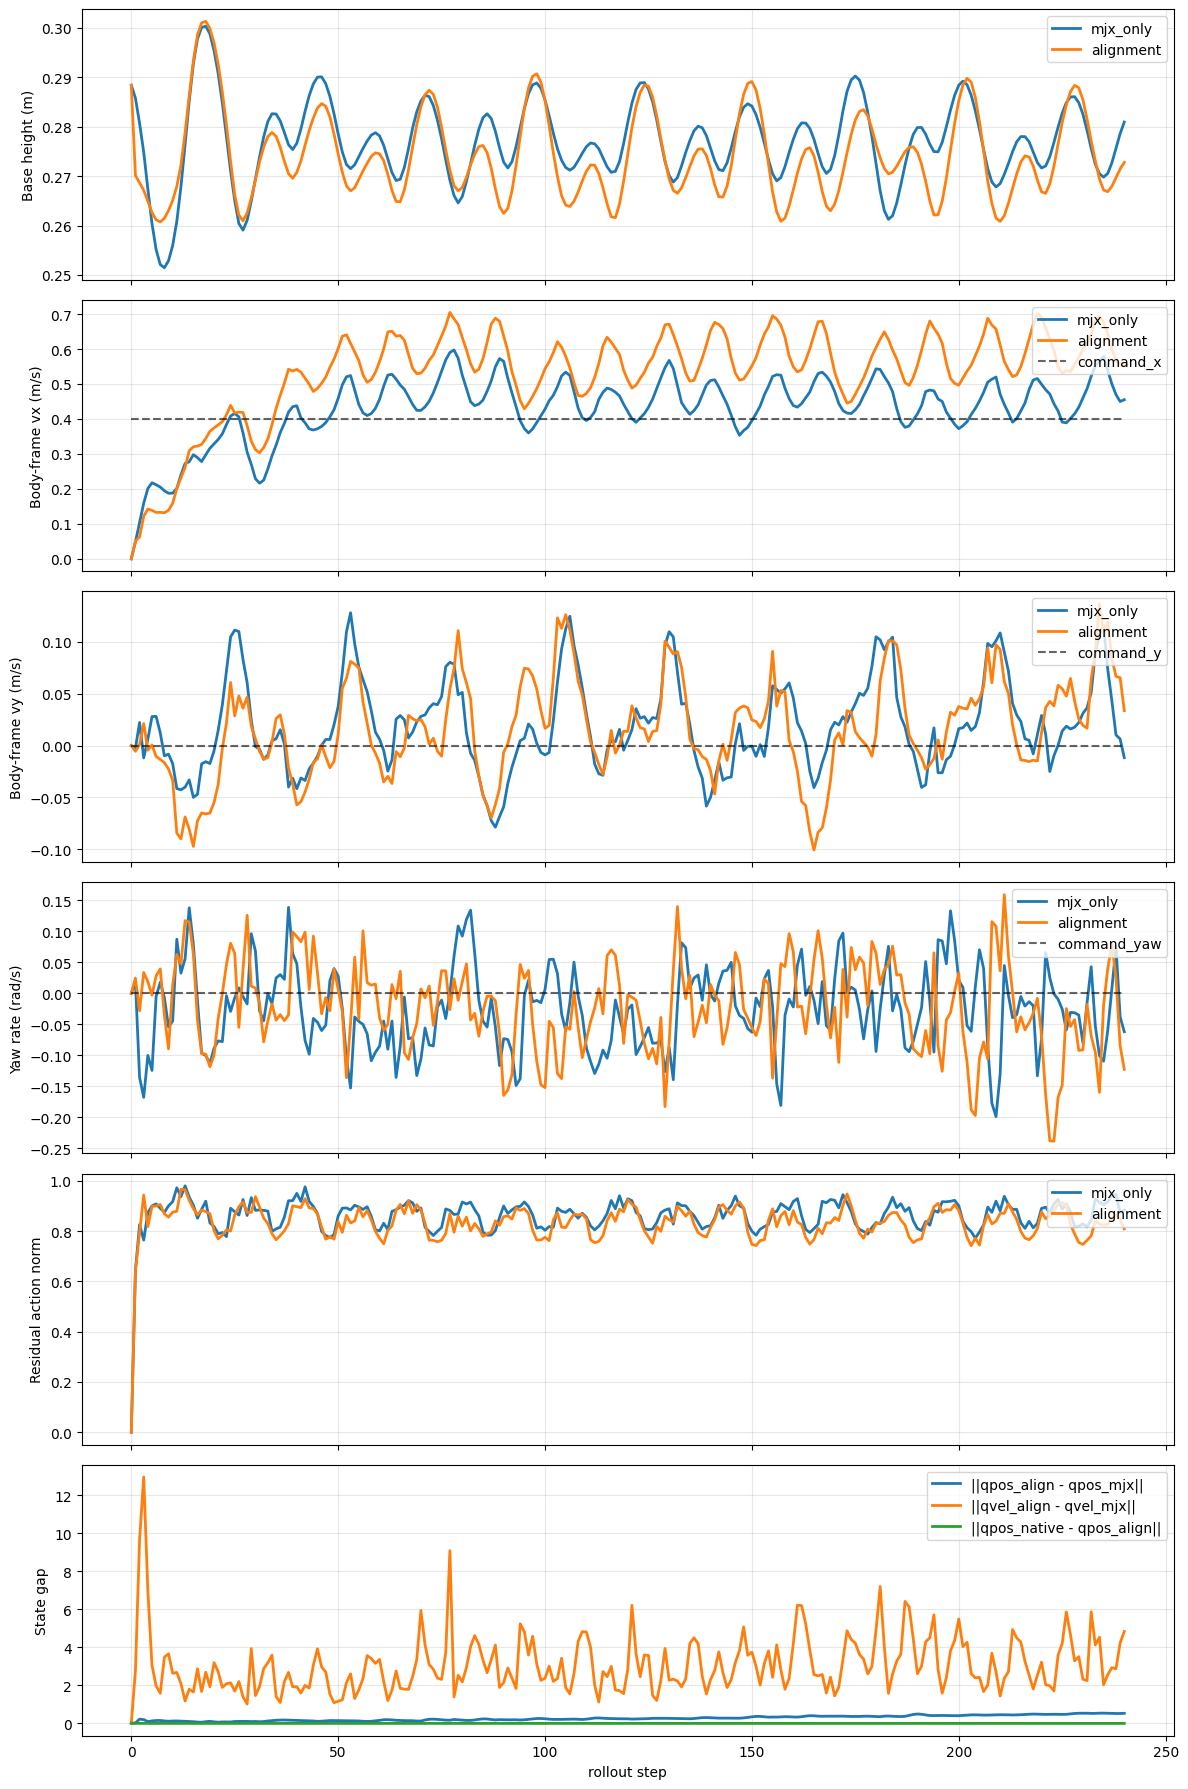

In [10]:
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)
for ax, (key, ylabel) in zip(
    axes[:-1],
    [
        ("base_height", "Base height (m)"),
        ("linvel_x", "Body-frame vx (m/s)"),
        ("linvel_y", "Body-frame vy (m/s)"),
        ("yaw_rate", "Yaw rate (rad/s)"),
        ("action_norm", "Residual action norm"),
    ],
):
    ax.plot(traj_mjx["step"], traj_mjx[key], label="mjx_only", linewidth=2)
    ax.plot(traj_align["step"], traj_align[key], label="alignment", linewidth=2)
    if key in {"linvel_x", "linvel_y", "yaw_rate"}:
        cmd_key = {"linvel_x": "command_x", "linvel_y": "command_y", "yaw_rate": "command_yaw"}[key]
        ax.plot(traj_mjx["step"], traj_mjx[cmd_key], "--", color="black", alpha=0.6, label=cmd_key)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

for key, label in (
    ("qpos_gap_align_vs_mjx", "||qpos_align - qpos_mjx||"),
    ("qvel_gap_align_vs_mjx", "||qvel_align - qvel_mjx||"),
    ("qpos_gap_native_vs_align", "||qpos_native - qpos_align||"),
):
    axes[-1].plot(gaps["step"], gaps[key], label=label, linewidth=2)
axes[-1].set_ylabel("State gap")
axes[-1].set_xlabel("rollout step")
axes[-1].grid(alpha=0.3)
axes[-1].legend(loc="upper right")
plt.tight_layout()
plt.show()

In [11]:
pd.DataFrame({
    "final_mjx": traj_mjx.iloc[-1],
    "final_alignment": traj_align.iloc[-1],
    "final_native": traj_native.iloc[-1],
})

,final_mjx,final_alignment,final_native
step,240.000000,240.000000,240.000000
base_height,0.280937,0.272770,0.272658
linvel_x,0.455139,0.551398,0.551024
linvel_y,-0.011613,0.033683,0.037364
yaw_rate,-0.061780,-0.122388,-0.119697
action_norm,0.883564,0.808791,0.808791
command_x,0.400000,0.400000,0.400000
command_y,0.000000,0.000000,0.000000
command_yaw,0.000000,0.000000,0.000000
reward,0.091855,0.082617,0.072226
